# Definindo o problema de negócio

Dataset - https://archive.ics.uci.edu/dataset/222/bank+marketing

Um banco português realizou campanhas de telemarketing para oferecer aos clientes um depósito a prazo (um investimento em que o cliente deixa o dinheiro aplicado por um período e recebe juros). Como a campanha envolve múltiplas tentativas de ligação, o banco quer aumentar a eficiência dessas chamadas identificando, com antecedência, **quais clientes têm maior chance de aceitar a oferta.**



**Por que isso é importante?**

Ligar para milhares de clientes é caro e consome tempo da equipe. Com um modelo preditivo, o banco pode:
- Priorizar os clientes com maior probabilidade de dizer “sim”
- Reduzir o custo operacional da campanha
- Aumentar a taxa de conversão (mais assinaturas com menos ligações)

# Configurando o ambiente (Cursor + S3 bucket + Github)

**GITHUB**

1. Crie um repositório, público ou privado, adicionando um README
2. Copie o link HTTPS pra usar depois.
3. Interface pra facilitar nos commits - Github Desktop - https://desktop.github.com/download/.
4. Após instalar o Github Desktop, abra ele, clique em Clonar repositório.
5. Cole o link que você copiou anteriormente, e enter.
6. Agora no Github Dektop em cima do repositório, clique com botão direito, e procure por encontrar repo, ou algo assim. Queremos ver onde o nosso repo foi salvo.

> README será gerado com AI ao final do curso, com projeto pronto.


---
**S3**

1. Acesse sua conta AWS, pra esse projeto, vou estar usando conta `root` mesmo, conta raiz.
2. Acessa IAM > IAM users > Create user > Adiciona policy AWSS3FullAcess ou restringe pra somente o que você precisa.
3. Depois de criada, clica no user, e acessa `Security credentials`.
4. Clica em `Create access key`, e salva o access key e secret key em algum lugar. Isso será usado lá no cursor pra que a gente consiga acessar os dados no S3.

Agora, precisamos **criar um bucket.**
- Clique no console da AWS, em S3.
- Clique em criar bucket > nomeie > confirme.
- Criar uma pasta raw, e adicione os arquivos lá dentro.

---

**CURSOR**

- Abra o cursor e localize a pasta do seu repositório.
- E pronto, agora você está dentro do seu repo.

- Criar pagina `requirements.txt`
- Criar ambiente virtual `.venv`
- Install requirements.



Agora, pra podermos acessar os dados na AWS, precisamos fazer umas configurações...
- Instalar AWS CLI, no meu caso, eu to usando mac, então vou instalar com esse comando aqui `brew install awscli`. Se você está usando Windows, pode tentar com Chocolatey, ou ir no link e instalar - https://aws.amazon.com/cli/. **Deixar manual/documento com instruções dentro do curso.**
    > O brew é basicamente um gerenciador de pacotes que facilita a instalação de ferramentas via terminal. 
- Depois de feito isso, vamos configurar as chaves. No terminal digite `aws configure `. E dai vai pedir as infos que salvamos anteriormente, e pronto.


Como habilitar o complete automático de código com IA? - https://dev.to/take0420/how-to-toggle-auto-completion-in-cursor-editor-12il

No Mac
1. Abra o editor do Cursor e pressione `CMD + SHIFT + P`
2. Digite `Enable cursor tab`
3. Pressione `ENTER`

No Windows
1. Abra o editor do Cursor e pressione `CTRL + SHIFT + P`
2. Digite `Enable cursor tab`
3. Pressione `ENTER`

# Carregando os dados e análise inicial

In [187]:
import boto3

In [ ]:
s3 = boto3.client('s3')

response = s3.list_buckets()

for bucket in response['Buckets']:
    print(bucket['Name'])

In [ ]:
response = s3.list_objects_v2(Bucket='bank-marketing-alura')

for obj in response['Contents']:
    print(obj['Key'])

In [190]:
import pandas as pd

In [191]:
obj = s3.get_object(Bucket='bank-marketing-alura', Key='raw/bank-full.csv')

dados = pd.read_csv(obj['Body'], sep=';')
dados.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [192]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


**Descrição dos dados:**

- **age:** idade do cliente
- **job:** tipo de trabalho (e.g., admin, technician, blue-collar)
- **marital:** estado civil (e.g., married, single)
- **education:** nível de educação
- **default:** Está inadimplente no crédito? (yes/no)
- **balance:** Saldo médio anual da conta em euros.
- **housing:** Tem empréstimo habitacional (yes/no)
- **loan:** Tem empréstimo pessoal. (yes/no)
- **contact:** tipo de comunicação do contato (ex.: celular, telefone)
- **day:** dia do mês do último contato
- **month:** mês do último contato (ex.: mai, jul)
- **duration:** duração do último contato, em segundos
- **campaign:** número de tentativas de contato feitas durante a campanha
- **pdays:** Número de dias que se passaram desde o último contato com o cliente em uma campanha anterior (numérico; -1 significa que o cliente não foi contatado anteriormente).
- **previous:** número de contatos realizados antes desta campanha para este cliente.
- **poutcome:** resultado da campanha de marketing anterior (categórico: 'failure', 'nonexistent', 'success').
- **Target (y):** indica se o cliente aderiu/assinou um depósito a prazo (YES/NO)

In [193]:
dados.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


- balance (saldo): média ~1362, mas desvio ~3045 e vai de -8019 a 102.127 → muito disperso e assimétrico, com outliers altos; saldo negativo indica clientes com déficit/cheque especial.

- campaign (nº de contatos na campanha atual): mediana 2, 75% até 3, mas máximo 63 → maioria recebe poucas tentativas, porém há casos de muitas insistências (outliers).

Vamos continuar a análise pra ver de forma mais aprofundada cada feature

In [ ]:
dados.isnull().sum()

Não tem nenhum nulo explícito, mas provavelmente vamos achar alguma coisa na análise mais aprofundada das features.

# Análise das variáveis qualitativas

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### 0. Variável alvo (y)

In [195]:
# Gráfico de contagem por classe com plotly. text_auto=True mostra o valor em cada barra
px.histogram(dados, x='y', text_auto=True).update_layout(bargap=0.4)

In [196]:
px.histogram(dados, x='y', histnorm='percent').update_layout(bargap=0.4).update_traces(texttemplate='%{y:.1f}%')

A variável-alvo y é altamente desbalanceada, com aproximadamente 88% das observações rotuladas como não (classe 0) e apenas 11% rotuladas como sim (classe 1).

Precisamos tomar cuidado com esse desbalanceamento porque a acurácia sozinha pode dar uma falsa sensação de bom desempenho. Por exemplo, corre risco de um modelo que classifica tudo como "não", ainda ter um resultado alto, sem de fato identificar quem tem chance de aderir ao deposito a prazo.

In [197]:
# converter target valores
dados['y'] = dados['y'].map({'yes': 1, 'no':0})

### Job (profissão)

In [200]:
# 1. Calcula taxa de conversão por profissão
# Como y é 0/1, a média representa a proporção de y=1
taxa = dados.groupby('job')['y'].mean() * 100
taxa

job
admin.           12.202669
blue-collar       7.274969
entrepreneur      8.271688
housemaid         8.790323
management       13.755551
retired          22.791519
self-employed    11.842939
services          8.883004
student          28.678038
technician       11.056996
unemployed       15.502686
unknown          11.805556
Name: y, dtype: float64

In [201]:
# 2. Conta quantas pessoas existem por profissão e por y
df_plot = (
    dados
    .groupby(['job', 'y']) #agrupa os dados em duas colunas
    .size() #conta quantas linhas existem em cada grupo
    .reset_index(name='count') #transforma dataframe normal, e nome count pra coluna contagens
)
df_plot

,job,y,count
0,admin.,0,4540
1,admin.,1,631
2,blue-collar,0,9024
3,blue-collar,1,708
4,entrepreneur,0,1364
5,entrepreneur,1,123
6,housemaid,0,1131
7,housemaid,1,109
8,management,0,8157
9,management,1,1301


In [202]:
# 3. Adiciona a taxa de conversão de cada profissão
df_plot['taxa'] = df_plot['job'].map(taxa)

In [203]:
import numpy as np

# 4. Cria label para aparecer nas barras
# y=1 mostra contagem + taxa
# y=0 mostra apenas contagem

# np.where(condição, valor_se_verdadeiro, valor_se_falso) — funciona como um "se/senão" para cada linha.

df_plot['label'] = np.where(
    df_plot['y'] == 1,
    df_plot['count'].astype(str) + ' (' + df_plot['taxa'].round(1).astype(str) + '%)',
    df_plot['count'].astype(str)
)

df_plot

,job,y,count,taxa,label
0,admin.,0,4540,12.202669,4540
1,admin.,1,631,12.202669,631 (12.2%)
2,blue-collar,0,9024,7.274969,9024
3,blue-collar,1,708,7.274969,708 (7.3%)
4,entrepreneur,0,1364,8.271688,1364
5,entrepreneur,1,123,8.271688,123 (8.3%)
6,housemaid,0,1131,8.790323,1131
7,housemaid,1,109,8.790323,109 (8.8%)
8,management,0,8157,13.755551,8157
9,management,1,1301,13.755551,1301 (13.8%)


In [204]:
# transforma y em string pra virar categoria (remove colorbar)
df_plot['y'] = df_plot['y'].astype(str)

fig = px.bar(
    df_plot,
    y='job', #profissoes no eixo y
    x='count', #a contagem no eixo x
    color='y', # cada valor de y ganha uma cor diferente
    barmode='group', # as barras de cada grupo ficam lado a lado ao inves de empilhadas
    orientation='h', #barras na horizontal
    text='label', #o texto que vai aparecer em cima das barras
    color_discrete_map={
        '0': '#636EFA',  # azul claro
        '1': '#EF553B'   # verde claro
    },
    labels={
        'y': 'Assinou depósito'
    } # renomeia a legenda de y para "Assinou depósito"
)

fig.update_traces(
    textposition='outside', #coloca o texto fora da barra
    cliponaxis=False #nao corta o texto na borda do grafico
)

fig.update_layout(
    width=1200, #largura do grafico
    height=700, #altura do grafico
    margin=dict(l=160, r=200, t=80, b=60) #margem do grafico
)
fig.show()

In [205]:
# SE QUISER ADICIONAR MAIS MARGEM

# transforma y em string pra virar categoria (remove colorbar)
df_plot['y'] = df_plot['y'].astype(str)

fig = px.bar(
    df_plot,
    y='job', #profissoes no eixo y
    x='count', #a contagem no eixo x
    color='y', # cada valor de y ganha uma cor diferente
    barmode='group', # as barras de cada grupo ficam lado a lado ao inves de empilhadas
    orientation='h', #barras na horizontal
    text='label', #o texto que vai aparecer em cima das barras
    color_discrete_map={
        '0': '#636EFA',  # azul claro
        '1': '#EF553B'   # verde claro
    },
    labels={
        'y': 'Assinou depósito'
    } # renomeia a legenda de y para "Assinou depósito"
)

fig.update_traces(
    textposition='outside', #coloca o texto fora da barra
    cliponaxis=False #nao corta o texto na borda do grafico
)

fig.update_layout(
    width=1200, #largura do grafico
    height=700, #altura do grafico
    margin=dict(l=160, r=200, t=80, b=60) #margem do grafico
)

fig.update_xaxes(
    range=[0, df_plot['count'].max() * 1.3] #
)

fig.show()

O que podemos ver aqui agora…

`blue-collar` representa trabalhadores operários.

- “blue-collar” tem uma das menores taxas de “Yes” (rótulo ~7,3%) mas ainda assim é um grupo muito grande em volume (barra longa), então impacta muito o total de “yes” e “no” mesmo com taxa baixa.
- “student” e “retired” se destacam pela conversão relativa (rótulos ~28,7% e ~22,8% de “Yes”), ou seja, dentro desses grupos a proporção de adesão é substancialmente maior do que em várias outras profissões.
- Temos ali uma categoria unknown, pode ser um valor ausente. Na etapa de processamento vamos precisar tratar essa feature, transformar em numérico para o modelo. Talvez faça sentido manter, já que o modelo pode aprender algum comportamento com essa categoria.

In [206]:
dados['job'].value_counts(normalize=True) * 100

job
blue-collar      21.525735
management       20.919688
technician       16.803433
admin.           11.437482
services          9.188029
retired           5.007631
self-employed     3.492513
entrepreneur      3.289023
unemployed        2.882042
housemaid         2.742695
student           2.074716
unknown           0.637013
Name: proportion, dtype: float64

Representa menos de 1% o unknown, poderíamos optar por remover, mas pra primeira modelagem vou optar por manter. Como falei, pode ser que o modelo encontre algum comportamento.

### Marital (estado civil)

In [207]:
# AQUI ADICIONAR TODOS OS CÓDIGOS FEITOS ANTERIORMENTE...

def plot_conversion_bar(df, feature_col, target_col='y'):

    taxa = df.groupby(feature_col)[target_col].mean() * 100

    df_plot = (
        df
        .groupby([feature_col, target_col]) #agrupa os dados em duas colunas
        .size() #conta quantas linhas existem em cada grupo
        .reset_index(name='count') #transforma dataframe normal, e nome count pra coluna contagens
    )

    df_plot['taxa'] = df_plot[feature_col].map(taxa)

    df_plot['label'] = np.where(
        df_plot['y'] == 1,
        df_plot['count'].astype(str) + ' (' + df_plot['taxa'].round(1).astype(str) + '%)',
        df_plot['count'].astype(str)
    )

    df_plot[target_col] = df_plot[target_col].astype(str)


    fig = px.bar(
        df_plot,
        y=feature_col, #profissoes no eixo y
        x='count', #a contagem no eixo x
        color=target_col, # cada valor de y ganha uma cor diferente
        barmode='group', # as barras de cada grupo ficam lado a lado ao inves de empilhadas
        orientation='h', #barras na horizontal
        text='label', #o texto que vai aparecer em cima das barras
        color_discrete_map={
            '0': '#636EFA',  # azul claro
            '1': '#EF553B'   # verde claro
        },
        labels={
            feature_col: feature_col.capitalize(),
            'count': 'Quantidade',
            target_col: 'Conversão'
        },
        title=f'Contagem e taxa de conversão por {feature_col}'
    )

    fig.update_traces(
        textposition='outside', #coloca o texto fora da barra
        cliponaxis=False #nao corta o texto na borda do grafico
    )

    fig.update_layout(
        width=1200, #largura do grafico
        height=700, #altura do grafico
        margin=dict(l=160, r=200, t=80, b=60) #margem do grafico
    )
    
    return fig
	

In [208]:
plot_conversion_bar(dados, 'marital')

- Single (~15%) — solteiros tem uma taxa de conversão maior — provavelmente menos compromissos financeiros como financiamento, filhos
- Married (~10%) — casados tem uma taxa de conversão menor — mais despesas fixas, menos dinheiro disponível para investir

### Education (educação)

In [209]:
plot_conversion_bar (dados, 'education')

- Tertiary (~15%) — ensino superior tem uma taxa maior, faz sentido — maior renda e interesse em investimento
- Primary (~9%) — ensino básico tem taxa menor, pela metade do tertiary

A taxa de conversão parece maior em tertiary do que em secondary/primary (o segmento “Yes” ocupa uma fatia maior nessa categoria).

In [210]:
dados['education'].value_counts(normalize=True) * 100

education
secondary    51.319369
tertiary     29.419831
primary      15.153392
unknown       4.107407
Name: proportion, dtype: float64

`unknown` representa mais de 1%, alta, então, vamos manter.

### Default (está inadimplente ou não)

In [211]:
plot_conversion_bar(dados, 'default')

- Podemos ver que quase todos os clientes estão em default = no (sem crédito in default).
- O grupo default = yes é muito pequeno. Quem tem crédito (está inadimplente) dificilmente tem dinheiro ou interesse em abrir um depósito a prazo

### Housing (tem empréstimo habitacional ou não)

In [212]:
plot_conversion_bar(dados, 'housing')

- Clientes sem empréstimo imobiliário (no):
    - - Taxa de conversão de 16.7%
    - Ou seja, clientes sem financiamento imobiliário (housing = no) apresentaram maior taxa de adesão ao depósito a prazo.
- Faz sentido, já que quem tem empréstimo imobiliário já tem um compromisso financeiro mensal alto (prestação da casa). Isso deixa menos dinheiro disponível e menos interesse em imobilizar capital num depósito a prazo.
- Já quem não tem financiamento imobiliário tem mais folga financeira e maior propensão a investir.

### Loan (tem empréstimo pessoal ou não)

In [213]:
plot_conversion_bar(dados, 'loan')

- Clientes com loan = no (sem empréstimo pessoal) têm maior taxa de assinatura do depósito a prazo (~12,7%) do que clientes com loan = yes (~6,7%).
- Então, na base analisada, pessoas sem empréstimo estão mais propensas a assinar.

### Contact

In [214]:
plot_conversion_bar(dados, 'contact')

Contato por celular tem uma taxa maior de conversão.

In [215]:
dados['contact'].value_counts(normalize=True) * 100

contact
cellular     64.774059
unknown      28.798301
telephone     6.427639
Name: proportion, dtype: float64

`unknown` tem um percentual bem alto, 29%. vamos manter também.

### Month (mês)

In [216]:
plot_conversion_bar(dados, 'month')

In [217]:
# 1. ordem correta dos meses
ordem_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# 2. calcula taxa por mês
taxa_mes = (
    dados.groupby('month')['y']
    .mean()
    .reindex(ordem_meses) * 100
)

# 3. transforma em dataframe
df_mes = taxa_mes.reset_index()
df_mes.columns = ['month', 'taxa']

# 4. gráfico
fig = px.line(
    df_mes,
    x='month',
    y='taxa',
    markers=True,
    category_orders={'month': ordem_meses}  # 🔥 mantém ordem correta
)

# 5. estilo
fig.update_traces(
    line=dict(color='#1ABC9C', width=3),
    marker=dict(size=8)
)

fig.update_layout(
    title='Taxa de Conversão do Depósito a Prazo (%) por Mês',
    xaxis_title='Mês',
    yaxis_title='Taxa de Conversão (%)',
    width=1000,
    height=400,
    template='plotly_white'
)

fig.show()

In [218]:
print(dados.groupby('month')['y'].agg(['mean', 'count']).round(2))


       mean  count
month             
apr    0.20   2932
aug    0.11   6247
dec    0.47    214
feb    0.17   2649
jan    0.10   1403
jul    0.09   6895
jun    0.10   5341
mar    0.52    477
may    0.07  13766
nov    0.10   3970
oct    0.44    738
sep    0.46    579


qui a gente tá olhando a taxa de conversão por mês — ou seja, em qual mês os clientes mais aceitaram assinar o depósito a prazo.

Olhando o gráfico, chama atenção alguns picos bem altos: março com 52%, setembro com 46%, outubro com 44% e dezembro com 47%. À primeira vista parece que esses são os melhores meses pra fazer campanha.

*Mas antes de tirar essa conclusão, precisamos checar quantos registros existem em cada mês. Março tem apenas 477 registros, dezembro 214, setembro 579 e outubro 738 — amostras relativamente pequenas comparadas a meses como maio (13.769). Taxas de conversão altas em amostras pequenas têm menor confiabilidade estatística, então esses valores podem não refletir o comportamento real dos clientes.*

*Outro ponto é que vamos precisar aplicar one-hot encoding nos meses, pois embora tenham uma ordem cronológica, o número do mês não tem relação proporcional com a conversão — o modelo não deve interpretar que "dezembro é 12 vezes janeiro".*

### Poutcome

In [ ]:
# verificar valores únicos de poutcome
print(dados['poutcome'].unique())


# verificar quantos valores únicos em cada categoria de poutcome
print(dados['poutcome'].value_counts())

aqui elas têm uma progressão natural de "nenhum contato" até "sucesso".

- unknown  → 0  (nunca contatado)
- failure  → 1  (foi contatado, não converteu)
- other    → 1  (foi contatado, resultado indefinido)
- success  → 2  (foi contatado, converteu)

Nesse caso você está simplificando para 3 níveis: **sem contato → contato sem conversão → contato com conversão**

*O `other` foi agrupado com `failure` por representar um contato que não resultou em conversão.*

# Analisando variáveis quantitativas

### Age (idade)

In [198]:
# cria histograma separado por y (0 e 1)
fig = px.histogram(
    dados,
    x="age",        # eixo X
    facet_col="y",  # separa em dois gráficos (y=0 e y=1)
    nbins=20,       # quantidade de bins (barras)
    title="Distribuição de idade por assinatura"
)

fig.show()

A idade se concentra principalmente entre ~30 e 50 anos em ambos os grupos, mas o grupo y = yes é bem menor. 

In [199]:
px.box(dados, x = 'age', color = 'y')

Podemos ver que não tem nenhum valor anormal, inconsistencia aqui. o mínimo começa em 18. 

**Grupo 0 (não assinou — azul):**

- Mediana em torno de **38-39 anos**.
- Concentração entre ~30 e ~48 anos (caixa).
- Outliers acima de 70, com alguns chegando a 90+.

**Grupo 1 (assinou — vermelho):**

- Mediana um pouco mais alta, em torno de **40 anos**.
- Caixa mais larga (~30 a ~50), ou seja, mais **dispersão** nas idades.
- Mesmos outliers na faixa de 70-95.

### Balance (saldo)

In [219]:
px.box(dados, x = 'balance', color = 'y')

Note que temos muito mais pontos considerados outliers (ponto fora da curva). São valores discrepantes do padrão geral daqueles dados. Podemos ver que na caixa roxa, temos um saldo minimo de -8019, no vermelho -3058. Neste caso, faz sentido ter um valor negativo, pois estamos trabalhando com saldo bancário. E valor máximo temos 100k aproximadamente. 

No nosso caso, não tem nada aqui que não faça sentido, esses valores discrepantes da maioria dos dados, podem ser importantes para a gente compreender o padrão dos nossos dados. Isso porque, apesar de ser uma pessoa que se difere, ela não está fora da realidade. Então temos que considerar isso no momento de avaliar um outlier.

### Day (dia)

In [220]:
# 1. calcular taxa por dia (igual você fez)
taxa_por_dia = dados.groupby('day')['y'].mean() * 100

# 2. transformar em dataframe (Plotly gosta disso)
df_line = taxa_por_dia.reset_index()
df_line.columns = ['day', 'taxa']

# 3. gráfico
fig = px.line(
    df_line,
    x='day',
    y='taxa',
    markers=True,   # igual marker='o'
    title='Taxa de Conversão do Depósito a Prazo (%) por Dia do Mês'
)

fig.update_layout(
    xaxis_title='Dia do Mês',
    yaxis_title='Taxa de Conversão (%)',
    width=1200,
    height=600
)

fig.show()

A taxa de conversão varia bastante conforme o dia do mês, com alguns picos (ex.: dias 1, 10, 22, 30) e vales (ex.: ~19–21 e fim do mês em alguns dias).

Isso pode indicar efeito de algumas estratégias, campanhas, disponibilidade de clientes, período de pagamento, contas, etc.

### Duration (duração da ligação)

In [221]:
px.box(dados, x = 'duration', color = 'y')

Para esta coluna, conseguimos ver que tem uma diferença na distribuição dos valores. No boxplot azul, que se refere a não aderência do investimento, temos valores mais concentrados em tempos menores. Já no vermelho, de aderência ao investimento, há valores maiores do tempo.

O tempo de último contato é no mínimo 0. Como estamos lidando com tempo, não é possível haver valores negativos, o que realmente não encontramos, então não há inconsistência. Ainda assim, há uma diferença na distribuição que pode ser importante para definirmos se a pessoa vai aderir ao investimento ou não.

Quem assina (Yes) tende a ter ligações mais longas. Essa variável acontece durante/depois da ligação, então se o objetivo for exclusivamente prever antes de ligar, ela não deve ser usada, porque pode ter vazamento de informação.

### Campaign

In [222]:
px.box(dados, x = 'campaign', color = 'y')

Podemos ver que número mínimo foi de 1. Máximo de 63. Novamente, não parece ter nenhuma inconsistência, o minimo de contato que poderia ter seria 1 mesmo.

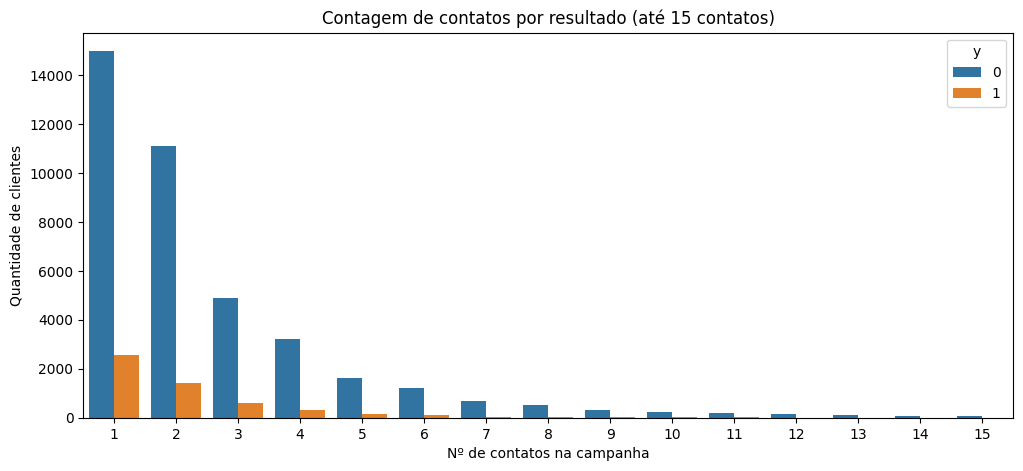

In [223]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=dados[dados['campaign'] <= 15], x='campaign', hue='y', ax=ax)
ax.set_title('Contagem de contatos por resultado (até 15 contatos)')
ax.set_xlabel('Nº de contatos na campanha')
ax.set_ylabel('Quantidade de clientes')
plt.show()

### Pdays (numero de dias que se passaram desde ultimo contato em uma campanha anterior, -1 significa que nao foi contactado)

In [224]:
# verificar quantos valores -1 tem
# verificar quantos valores -1 tem
print(dados['pdays'].value_counts())
print("\nProporção de valores -1:")
print(dados['pdays'].value_counts(normalize=True))

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
        ...  
 449        1
 452        1
 648        1
 595        1
 530        1
Name: count, Length: 559, dtype: int64

Proporção de valores -1:
pdays
-1      0.817367
 182    0.003694
 92     0.003251
 91     0.002787
 183    0.002787
          ...   
 449    0.000022
 452    0.000022
 648    0.000022
 595    0.000022
 530    0.000022
Name: proportion, Length: 559, dtype: float64


- Com uma proporção tão alta, o pdays numérico perde muito valor preditivo. O que realmente importa é se o cliente foi contatado ou não.
- Recomendação: dropar pdays e ficar só com a flag contactado ou não
- Com 82% de -1, a variância real do pdays é mínima
Imputar mediana nos 82% restantes seria inventar dados demais
A informação útil está na presença ou ausência de contato anterior, não nos dias em si
Simplifica o modelo sem perder informação relevante

### Previous (número de contatos realizados antes da campanha pra esse cliente)

In [225]:
# Checa a correlação
print(dados[dados['pdays'] == -1]['previous'].value_counts())

previous
0    36954
Name: count, dtype: int64


In [226]:
print(dados['previous'].value_counts())


previous
0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
24         5
27         5
21         4
29         4
25         4
30         3
38         2
37         2
26         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: count, dtype: int64


- pdays → dropar, pois é 100% redundante com previous (sempre que pdays == -1, previous == 0).
- previous → binarizar, pois 82% dos valores são 0 e os demais decaem rapidamente:
    - 0 = nunca foi contatado antes
    - 1 = foi contatado ao menos uma vez

## Divisão dos dados


***Por que dividir os dados antes de transformar?***

*Antes de aplicar qualquer transformação (normalização, codificação, etc.), precisamos separar os dados em treino e teste. O motivo é: o conjunto de teste simula dados novos que o modelo nunca viu. Se transformarmos tudo junto, as estatísticas do teste "vazam" para o treino — o modelo aprende informações que não deveria ter, e a avaliação de desempenho fica otimista demais. Isso é chamado de **data leakage** (vazamento de dados). Por isso, toda transformação será ajustada apenas nos dados de treino e depois aplicada ao teste.*

In [44]:
from sklearn.model_selection import train_test_split

X = dados.drop('y', axis=1)
y = dados['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [45]:
print(X_train.shape, X_test.shape)

(33908, 16) (11303, 16)


In [46]:
print(y_train.mean(), y_test.mean())

0.1169930399905627 0.1169600990887375


In [47]:
px.bar(y_train.value_counts(normalize=True)*100)

Podemos ver que se manteve a questão do desbalanceamento, o split não distorceu a proporção das classes, treino ainda reflete o desbalanceamento que vimos anteriormente. Após a codificação, vamos aplicar técnicas para tratar o desbalanceamento (como SMOTE, undersampling, etc.).

## Pré processamento e feature engineering variáveis categóricas


| Feature | Tipo | Método Encoding |
|---|---|---|
| `job` | Categórica nominal | One-Hot Encoding (variáveis dummies) |
| `marital` | Categórica nominal | One-Hot Encoding (variáveis dummies) |
| `contact` | Categórica nominal | One-Hot Encoding (variáveis dummies) |
| `month` | Categórica  | One-hot-encoding |
| `education` | Categórica ordinal (categorias com ordem) | Ordinal Encoding |
| `default` | Binário | Binary Encoding |
| `housing` | Binário | Binary Encoding |
| `loan` | Binário | Binary Encoding |
| `poutcome` | Categórico ordinal | Label Encoding |

### Month, job, marital, contact

In [227]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['month', 'job', 'marital', 'contact']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])



KeyError: "None of [Index(['month', 'job', 'marital', 'contact'], dtype='object')] are in the [columns]"

In [49]:
train_encoded = pd.DataFrame(ohe.transform(X_train[cat_cols]), 
                            columns=ohe.get_feature_names_out(cat_cols), 
                            index=X_train.index)

test_encoded = pd.DataFrame(ohe.transform(X_test[cat_cols]), 
                            columns=ohe.get_feature_names_out(cat_cols), 
                            index=X_test.index)

In [50]:
train_encoded.columns

Index(['month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'contact_cellular', 'contact_telephone',
       'contact_unknown'],
      dtype='object')

In [51]:
X_train = pd.concat([X_train.drop(columns=cat_cols), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), test_encoded], axis=1)

X_train.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
24915,58,tertiary,no,0,yes,no,18,265,1,188,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
11794,47,secondary,no,287,no,no,20,63,1,-1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1279,35,tertiary,no,797,yes,no,8,81,1,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
913,34,secondary,no,627,yes,no,7,283,2,-1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5554,35,secondary,no,91,yes,no,23,185,4,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [52]:
X_train.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'month_apr',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='object')

### Education

In [53]:
# EDUCATION

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories =[['unknown', 'primary', 'secondary', 'tertiary']],
                    handle_unknown = 'use_encoded_value',
                    unknown_value = -1)

oe.fit(X_train[['education']])




OrdinalEncoder(categories=[['unknown', 'primary', 'secondary', 'tertiary']],
               handle_unknown='use_encoded_value', unknown_value=-1)

In [54]:
X_train['education_ord'] = oe.transform(X_train[['education']])
X_test['education_ord'] = oe.transform(X_test[['education']])

In [55]:
X_train = X_train.drop(columns=['education'])
X_test = X_test.drop(columns=['education'])

In [56]:
X_train.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord'],
      dtype='object')

### Default, housing, loan

In [57]:
# DEFAULT, HOUSING, LOAN

binary_map = {'yes':1, 'no':0}

for col in ['default', 'housing', 'loan']:
    X_train[f'{col}_bin'] = X_train[col].map(binary_map)
    X_test[f'{col}_bin'] = X_test[col].map(binary_map)

# Dropar colunas originais
X_train = X_train.drop(columns=['default', 'housing', 'loan'])
X_test = X_test.drop(columns=['default', 'housing', 'loan'])

X_train.columns


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'month_apr', 'month_aug', 'month_dec', 'month_feb',
       'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'education_ord', 'default_bin', 'housing_bin',
       'loan_bin'],
      dtype='object')

In [58]:
# POUTCOME

poutcome_map = {'unknown':0, 'failure':1, 'other':1, 'success':2}

X_train['poutcome'] = X_train['poutcome'].map(poutcome_map)
X_test['poutcome'] = X_test['poutcome'].map(poutcome_map)

X_train.head()




,age,balance,day,duration,campaign,pdays,previous,poutcome,month_apr,month_aug,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,education_ord,default_bin,housing_bin,loan_bin
24915,58,0,18,265,1,188,1,1,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,3.0,0,1,0
11794,47,287,20,63,1,-1,0,0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0,0,0
1279,35,797,8,81,1,-1,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0,1,0
913,34,627,7,283,2,-1,0,0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0,1,0
5554,35,91,23,185,4,-1,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0,1,0


In [59]:
X_train['poutcome'].unique()

array([1, 0, 2])

In [60]:
X_test['poutcome'].unique()

array([0, 1, 2])

## Pré processamento e feature engineering de variáveis numéricas

| Feature | Tipo | Método Encoding |
|---|---|---|
| `age` | Discreta/continua | Normalização |
| `balance` | Contínuo (com outliers) | Como tem bastante outliers, aplicar transformação log + scaling |
| `day` | Numérica discreta | Manter como está |
| `duration` | Contínuo (calda longa) | Aplicar transformação log |
| `campaign` | Discreta (with outliers) | Criar bins pra reduzir outliers |
| `pdays` | Numérico (-1 não contactado) | Dropar coluna, muito correlacionada ao `previous` |
| `previous` | Numérico | Binarizar, pois 82% dos valores são 0 e os demais decaem rapidamente |

### Age

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train['age_t'] = scaler.fit_transform(X_train[['age']])
X_test['age_t'] = scaler.transform(X_test[['age']])

X_train.drop(columns=['age'], inplace=True)
X_test.drop(columns=['age'], inplace=True)

X_train.head()

,balance,day,duration,campaign,pdays,previous,poutcome,month_apr,month_aug,month_dec,...,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,education_ord,default_bin,housing_bin,loan_bin,age_t
24915,0,18,265,1,188,1,1,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,3.0,0,1,0,1.609393
11794,287,20,63,1,-1,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0,0,0,0.573629
1279,797,8,81,1,-1,0,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,3.0,0,1,0,-0.556295
913,627,7,283,2,-1,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0,1,0,-0.650456
5554,91,23,185,4,-1,0,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,2.0,0,1,0,-0.556295


In [62]:
X_train.columns

Index(['balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'month_apr', 'month_aug', 'month_dec', 'month_feb',
       'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'education_ord', 'default_bin', 'housing_bin',
       'loan_bin', 'age_t'],
      dtype='object')

### Balance

- A coluna `balance` tem valores extremos e negativos. 
- O log ele comprime os outliers (mas log não aceita negativos nem zero)
- Então separou-se o sinal em outra variável, pra manter ainda a interpretação financeira.
- E após apliquei o scaler pra normalizar a escala do saldo. 

In [63]:
X_train['balance_sign'] = np.sign(X_train['balance'])
X_test['balance_sign'] = np.sign(X_test['balance'])

X_train['balance_log'] = np.log(X_train['balance'].abs() + 1)
X_test['balance_log'] = np.log(X_test['balance'].abs() + 1)

scaler_balance = StandardScaler()

X_train['balance_log'] = scaler_balance.fit_transform(X_train[['balance_log']])
X_test['balance_log'] = scaler_balance.transform(X_test[['balance_log']])


X_train.drop(columns=['balance'], inplace=True)
X_test.drop(columns=['balance'], inplace=True)

X_train.columns





Index(['day', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'education_ord', 'default_bin', 'housing_bin',
       'loan_bin', 'age_t', 'balance_sign', 'balance_log'],
      dtype='object')

### Duration

- Distribuição muito assimétrica (maioria das ligações é curta, mas algumas são muito longas). 
- O log resolve isso da mesma forma que o balance.
- O log diminui a amplitude dos valores.

In [64]:
X_train['duration_t'] = X_train['duration'].replace(0,1)
X_test['duration_t'] = X_test['duration'].replace(0,1)

X_train['duration_t'] = np.log(X_train['duration_t'])
X_test['duration_t'] = np.log(X_test['duration_t'])

scaler_duration = StandardScaler()

X_train['duration_t'] = scaler_duration.fit_transform(X_train[['duration_t']])
X_test['duration_t'] = scaler_duration.transform(X_test[['duration_t']])

X_train.drop(columns=['duration'], inplace=True)
X_test.drop(columns=['duration'], inplace=True)



In [65]:
X_train.columns

Index(['day', 'campaign', 'pdays', 'previous', 'poutcome', 'month_apr',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord', 'default_bin', 'housing_bin', 'loan_bin', 'age_t',
       'balance_sign', 'balance_log', 'duration_t'],
      dtype='object')

### Campaign

- Se olharmos lá o gráfico, vemos que a maioria dos clientes são contatados 1 vez, 
- poucos são contatados 2 ou 3 vezes, 
- e poucos são contatados mais do que isso. 

---
- 1 contato - Primeiro contato — alta chance de ser neutro
- 2-3 contatos - Seguimento normal da campanha
- 4-6 contatos - Insistência — pode estar resistindo
- 7+ contatosMuito insistente — provavelmente não vai converter

Isso elimina o problema dos outliers e é mais interpretável.

In [66]:
bins = [0, 1, 3, 6, float('inf')]
labels = ['1_contato', '2_3_contatos', '4_6_contatos', '7_contatos']

X_train['campaign_bin'] = pd.cut(X_train['campaign'], bins=bins, labels=labels, right=False)
X_test['campaign_bin'] = pd.cut(X_test['campaign'], bins=bins, labels=labels, right=False)

#Dropar a coluna original
X_train.drop(columns=['campaign'], inplace=True)
X_test.drop(columns=['campaign'], inplace=True)


#get_dummies() transformar as categorias em numeros binarios
X_train = pd.get_dummies(X_train, columns=['campaign_bin'])
X_test = pd.get_dummies(X_test, columns=['campaign_bin'])


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)



In [67]:
X_train.columns

Index(['day', 'pdays', 'previous', 'poutcome', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord', 'default_bin', 'housing_bin', 'loan_bin', 'age_t',
       'balance_sign', 'balance_log', 'duration_t', 'campaign_bin_1_contato',
       'campaign_bin_2_3_contatos', 'campaign_bin_4_6_contatos',
       'campaign_bin_7_contatos'],
      dtype='object')

In [68]:
X_train.head()

,day,pdays,previous,poutcome,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,...,housing_bin,loan_bin,age_t,balance_sign,balance_log,duration_t,campaign_bin_1_contato,campaign_bin_2_3_contatos,campaign_bin_4_6_contatos,campaign_bin_7_contatos
24915,18,188,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,1.609393,0,-2.479912,0.446596,False,True,False,False
11794,20,-1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.573629,1,-0.036629,-1.091229,False,True,False,False
1279,8,-1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,-0.556295,1,0.403082,-0.822206,False,True,False,False
913,7,-1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,-0.650456,1,0.299721,0.516944,False,True,False,False
5554,23,-1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,-0.556295,1,-0.528987,0.061899,False,False,True,False


### Pdays

In [69]:
# Dropar a coluna pdays
X_train.drop(columns=['pdays'], inplace=True)
X_test.drop(columns=['pdays'], inplace=True)


### Previous

In [70]:
X_train['previous'] = (X_train['previous']> 0).astype(int)
X_test['previous'] = (X_test['previous']> 0).astype(int)



In [71]:
X_train['previous']

24915    1
11794    0
1279     0
913      0
5554     0
        ..
10010    0
26216    0
15941    0
16952    0
34781    0
Name: previous, Length: 33908, dtype: int64

<img src="imagens_ilustrativas/undersampling_oversampling.png" alt="Undersampling e oversampling" width="450"/>

# Balanceamento de classes

<img src="/Users/leticiapires/Desktop/dev/BankMarketing/imagens_ilustrativas/undersampling_oversampling.png" width="800">

Dado o desequilíbrio de classes na variável alvo, aplicaremos uma estratégia de reamostragem combinada para equilibrar os dados de treinamento. 

Então será usado:

- **Oversampling** → aumenta a classe minoritária, selecionando amostras aleatoriamente até atingir uma proporção desejada.
- **Undersampling** → reduz a classe majoritária de forma aleatória até atingir a proporção desejada.

Primeiro aumentaremos a amostra da classe minoritária para 50% da classe majoritária usando ****RandomOverSampler**** e, em seguida, reduziremos a amostra da classe majoritária para corresponder a esse novo tamanho usando ****RandomUnderSampler****. Isso equilibrará o conjunto de dados, preservando mais exemplos de treinamento do que uma redução completa da amostra e reduzindo o risco de sobreajuste, overfitting.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

over = RandomOverSampler(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

pipeline = Pipeline([('over', over), ('under', under)])

In [ ]:

X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts(normalize=True)

y_resampled.value_counts(normalize=True)


y
0    0.5
1    0.5
Name: proportion, dtype: float64

# Rodando o primeiro modelo

Agora que já preparamos nossos dados, chegou a hora de treinar nosso modelo. 

Pra isso, podemos começar com um baseline rápido usando Regressão Logística, um modelo simples, que treina em alguns segundos e já nos dá uma referência de performance. 

> Nessa primeira rodada, vamos usar ****todas as features disponíveis**** — incluindo `duration`. Mas atenção: `duration` é a duração da ligação, uma informação que só existe ****depois**** que a chamada aconteceu. Ou seja, em produção nunca teríamos esse dado antes de ligar. Usá-la aqui é intencional — queremos ver o impacto que ela causa nos resultados e entender por que não podemos depender dela no modelo final.


Os resultados provavelmente serão muito melhores nessa primeira análise — e isso é justamente o ponto de atenção. Quando um modelo utiliza informações que não estariam disponíveis no momento da previsão, temos um caso de vazamento de dados (data leakage).

Na próxima etapa, vamos remover `duration` e comparar o desempenho dos modelos em um cenário mais realista.

```
PROMPT: 
Gere um modelo baseline LogisticRegression, usando os dados balanceados, e traga os valores de validação, precision, recall, accuracy.
```

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Treinando o modelo baseline
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_resampled, y_resampled)

# Previsões no conjunto de treino balanceado
y_pred = logreg.predict(X_test)

# Mostrando os resultados de validação
print("Classification Report (Baseline Logistic Regression - Dados Balanceados):\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report (Baseline Logistic Regression - Dados Balanceados):

              precision    recall  f1-score   support

           0     0.9742    0.8232    0.8923      9981
           1     0.3848    0.8351    0.5268      1322

    accuracy                         0.8246     11303
   macro avg     0.6795    0.8291    0.7096     11303
weighted avg     0.9052    0.8246    0.8496     11303



O que temos aqui… o modelo podemos ver que trouxe uma acuracia de aproximadamente 83%, mas como a gente tem uma base desbalanceada, é importante não considerar somente isso, já que quando quase todo mundo é “não”, prever sempre “não” **parece** um bom modelo na acurácia, **mesmo sem ter aprendido nada** sobre quem é “sim”.

Por isso, além da acurácia, precisamos analisar métricas como precision e recall.

Aqui, o recall da classe positiva foi de aproximadamente 84%, indicando que o modelo consegue encontrar a maior parte dos clientes que realmente aceitariam a oferta. Em contrapartida, a precision ficou em torno de 38%, o que significa que, entre todos os clientes classificados como positivos, apenas cerca de 38% realmente converteriam.

Na prática, isso indica uma quantidade significativa de falsos positivos — ou seja, muitos clientes seriam contatados sem efetivamente converter.

Essas métricas ajudam a entender o comportamento do modelo, mas a definição do que é um “bom resultado” depende do contexto de negócio. A empresa precisa avaliar, por exemplo, o impacto entre:

- gastar recursos entrando em contato com clientes que não irão converter;
- ou deixar de contatar clientes que poderiam aceitar a oferta.

Mais adiante, vamos traduzir essas métricas em decisão prática, analisando como escolher um threshold mais adequado para equilibrar conversão, custo operacional e potencial de lucro da campanha.

# Testando o LazyClassifier

Bom, agora que a gente fez esse modelo inicial, eu quero testar, ou fazer uma varredura inicial, uma exploração inicial em alguns modelos pra ver o que pode me trazer um resultado melhor. Pra isso eu quero mostrar uma biblioteca pra vocês que facilita bastante, pra não precisar ficar testando dezenas de modelos na mão. O **LazyClassifier** (biblioteca `lazypredict`) treina **vários classificadores** com configuração padrão e devolve uma **tabela comparativa** de desempenho.

O ‘melhor’ da tabela vira **candidato** para depois **ajustar**, balancear e alinhar à **precision/recall** do negócio.”

Um ponto importante: como ele roda vários modelos em sequência, ****pode demorar até 30 minutos**** dependendo da máquina.

In [83]:
from lazypredict.Supervised import LazyClassifier

In [ ]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
models, predictions = clf.fit(X_resampled, X_test, y_resampled, y_test)

models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LGBMClassifier,0.855171,0.864183,0.931537,0.874069,0.917819,0.855171,0.419868
SVC,0.844643,0.847065,0.920540,0.865348,0.911776,0.844643,38.855392
NuSVC,0.817836,0.844027,0.915748,0.845268,0.910185,0.817836,61.822820
RidgeClassifierCV,0.811997,0.829564,0.905735,0.840293,0.905277,0.811997,0.160087
LinearDiscriminantAnalysis,0.811908,0.829514,0.905733,0.840225,0.905260,0.811908,0.220745
RidgeClassifier,0.811908,0.829514,0.905732,0.840225,0.905260,0.811908,0.141499
LinearSVC,0.820490,0.829124,0.906728,0.846562,0.905154,0.820490,0.187148
LogisticRegression,0.824471,0.828753,0.906983,0.849486,0.905095,0.824471,0.141399
CalibratedClassifierCV,0.823144,0.828658,0.906728,0.848501,0.905038,0.823144,0.404479


Aqui no caso do Lazy Classifier, ele tá trazendo a acurácia e balanced accuracy. A gente vai usar ela, porque é mais adequada pro nosso contexto de desbalanceamento, já que traz a média de acertos obtida em cada classe.

Lembrar que também podem não estar todos os modelos aqui, talvez na execução pode ter dado erro em algum. 

Analisando os modelos, os que se sairam melhor:

1. LightGBM

- Balanced Accuracy: **0.864**
- ROC AUC: **0.932**
- Accuracy: **0.855**
- Tempo: **0.33s**

Foi o modelo mais equilibrado entre: capacidade preditiva, separação entre classes, e eficiência computacional.

2. Support Vector Classifier

- Balanced Accuracy: **0.847**
- ROC AUC: **0.921**
- Accuracy: **0.845**
- Tempo: **41s**

Apresentou desempenho muito forte nas métricas, especialmente na separação entre classes. Porém, o custo computacional foi significativamente maior.

Esses modelos vocês ainda não viram, vão aprender mais pra frente, mas em resumo…

- O **LGBMClassifier (LightGBM)** é um modelo baseado em árvores de decisão e técnicas de boosting, muito utilizado em aplicações reais por combinar alta performance e velocidade.
- Já o **SVC (Support Vector Classifier)** busca encontrar a melhor separação possível entre as classes no espaço de dados, sendo bastante poderoso para problemas de classificação.

Mas também fica aqui a sugestão pra explorarem mais esses modelos, entender mais como eles funcionam.

## 

# Modelagem pré ligação

<img src="/Users/leticiapires/Desktop/dev/BankMarketing/imagens_ilustrativas/modelagem_bank_marketing.png" width="700">

Em campanhas de marketing no mundo real, as decisões raramente acontecem de uma vez só. O processo costuma seguir um funil — e dependendo da empresa, do contexto e da maturidade do time de dados, esse funil pode ser mais simples  ou mais sofisticado.

A gente pode pensar nesse processo em 3 momentos diferentes.

**📋 Momento 1 — Antes de ligar: quem merece atenção?**
Nessa fase, ainda não houve nenhum contato. As informações disponíveis são o que já sabemos sobre o cliente e as decisões que podemos tomar como equipe de campanha. Do lado do cliente, temos dados estáticos — idade, saldo, educação, profissão, histórico de contatos anteriores. Do lado da campanha, temos variáveis controláveis — canal de contato, dia e mês escolhido para a abordagem.

**📞 Momento 2 — Durante a ligação: como conduzir a conversa?**

Assim que a ligação começa, um novo dado entra em cena — a duração da chamada (`duration`). Tempo de conversa é engajamento. Engajamento é sinal de interesse. Nessa etapa, o modelo passa a funcionar em tempo real, estimando a probabilidade de sucesso conforme a conversa avança. Um cliente que permanece mais tempo na linha pode estar próximo de dizer sim — e isso pode mudar completamente a abordagem do atendente naquele momento.

**🔄 Momento 3 — Depois da ligação: o que podemos melhorar?**

Com a chamada encerrada e o resultado conhecido, fecha-se o ciclo. Agora temos o quadro completo — quem foi contatado, como foi a conversa e qual foi o desfecho. Com isso, podemos ter insights de quais combinações de campanhar e perfis deram certo, retreinar modelos com os novos updates, refinar campanhar futuras, e melhorar algumas etapas.

**No nosso projeto, vamos focar no Momento 1.**

Com esse modelo conseguimos responder a pergunta central da campanha: **Esse cliente vale a pena contatar, dado o que sabemos sobre ele e o contexto da campanha?**

Isso já permite que o banco seja mais eficiente e entender quais clientes priorizar, reduzir ligações desnecessárias e aumentar a taxa de conversão do call center.

In [ ]:
features_pre_call = ['day', 'previous', 'poutcome', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord', 'default_bin', 'housing_bin', 'loan_bin', 'age_t',
       'balance_sign', 'balance_log', 'campaign_bin_1_contato',
       'campaign_bin_2_3_contatos', 'campaign_bin_4_6_contatos',
       'campaign_bin_7_contatos']

In [85]:
X_resampled.columns

Index(['day', 'previous', 'poutcome', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord', 'default_bin', 'housing_bin', 'loan_bin', 'age_t',
       'balance_sign', 'balance_log', 'duration_t', 'campaign_bin_1_contato',
       'campaign_bin_2_3_contatos', 'campaign_bin_4_6_contatos',
       'campaign_bin_7_contatos'],
      dtype='object')

In [87]:
X_train_pre = X_train[features_pre_call]
X_test_pre = X_test[features_pre_call]

In [93]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)

X_train_bal, y_train_bal = pipeline.fit_resample(X_train_pre, y_train)

models, predictions = clf.fit(X_train_bal, X_test_pre, y_train_bal, y_test)

models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LGBMClassifier,0.819517,0.742277,0.799142,0.840672,0.877039,0.819517,0.338808
SVC,0.812085,0.719366,0.787014,0.833730,0.869274,0.812085,63.616713
NuSVC,0.800142,0.708666,0.769344,0.824612,0.865120,0.800142,88.270418
LinearSVC,0.750774,0.703025,0.773024,0.789491,0.862411,0.750774,0.237807
LogisticRegression,0.748120,0.702835,0.773478,0.787574,0.862384,0.748120,0.142479
CalibratedClassifierCV,0.738123,0.702752,0.773022,0.780337,0.862568,0.738123,0.456021
RidgeClassifierCV,0.745023,0.702066,0.772757,0.785303,0.862171,0.745023,0.157052
LinearDiscriminantAnalysis,0.745023,0.701738,0.772740,0.785287,0.862057,0.745023,0.246649
RidgeClassifier,0.745023,0.701738,0.772741,0.785287,0.862057,0.745023,0.141347


**SELECIONANDO OS MELHORES MODELOS PRA PREDIÇÃO PRÉ-LIGAÇÃO**

Bom, vou selecionar aqui os 3 melhores modelos, considerando o balanced accuracy, ROC AUC (mede a capacidade do modelo de separar as classes), f1 score pra ter um equilibrio entre o precision e recall, e o tempo de treino. 

| Modelo | Balanced Accuracy | ROC AUC | f1 score | Tempo | Observação |
| --- | --- | --- | --- | --- | --- |
| LGBMClassifier | 0.742277 | 0.799142 | 0.840672 | 0.311084 |  |
| LogisticRegression | 0.702835 | 0.773478 | 0.787574 | 0.137865 | Vamos considerar já que são modelos já vistos por vocês |
| RandomForestClassifier | 0.688115 | 0.786639 | 0.867108 | 2.414998 | Vamos considerar já que são modelos já vistos por vocês |

Aqui pode ser até que tivessem outros modelos melhores, provavelmente ele não rodou todos, pode ter dado erro em algum, eu posso ver aqui na tabela que o XGBoost que é um modelo bom, não aparece aqui. A gente também colocou ali um parametro pra minimizar essas mensagens, então é isso.

# Cross validation melhores candidatos/modelos

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

In [95]:
candidatos = {
    'LightGBM': LGBMClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [96]:
resultados_cv = []

for nome, modelo in candidatos.items():
    print(f"\n Cross-validando: {nome}")

    metricas_fold = {
        'Accuracy':[],
        'Precision':[],
        'Recall':[],
        'F1':[],
        'ROC AUC':[]
    }


    for fold, (idx_treino, idx_val) in enumerate(kf.split(X_train_pre, y_train), start=1):
        print(f" Fold {fold}/5...")

        X_treino_fold = X_train_pre.iloc[idx_treino]
        y_treino_fold = y_train.iloc[idx_treino]
        X_val_fold = X_train_pre.iloc[idx_val]
        y_val_fold = y_train.iloc[idx_val]


        X_bal, y_bal = pipeline.fit_resample(X_treino_fold, y_treino_fold)

        modelo.fit(X_bal, y_bal)

        #predições
        y_pred = modelo.predict(X_val_fold)
        y_prob = modelo.predict_proba(X_val_fold)[:, 1]

        metricas_fold['Accuracy'].append(accuracy_score(y_val_fold, y_pred))
        metricas_fold['Precision'].append(precision_score(y_val_fold, y_pred))
        metricas_fold['Recall'].append(recall_score(y_val_fold, y_pred))
        metricas_fold['F1'].append(f1_score(y_val_fold, y_pred))
        metricas_fold['ROC AUC'].append(roc_auc_score(y_val_fold, y_prob))



    resultados_cv.append({
        'Modelo': nome,
        'Accuracy': np.mean(metricas_fold['Accuracy']),
        'Precision': np.mean(metricas_fold['Precision']),
        'Recall': np.mean(metricas_fold['Recall']),
        'F1': np.mean(metricas_fold['F1']),
        'ROC AUC': np.mean(metricas_fold['ROC AUC']),
        'Std ROC AUC': np.std(metricas_fold['ROC AUC'])
    })


 Cross-validando: LightGBM
 Fold 1/5...
 Fold 2/5...
 Fold 3/5...
 Fold 4/5...
 Fold 5/5...

 Cross-validando: Random Forest
 Fold 1/5...
 Fold 2/5...
 Fold 3/5...
 Fold 4/5...
 Fold 5/5...

 Cross-validando: Logistic Regression
 Fold 1/5...
 Fold 2/5...
 Fold 3/5...
 Fold 4/5...
 Fold 5/5...


In [97]:
cv_df = pd.DataFrame(resultados_cv).set_index('Modelo')

display(cv_df.sort_values(by='ROC AUC', ascending=False).style.highlight_max(
    subset=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC AUC'
    ],
    color='lightgreen'
))

,Accuracy,Precision,Recall,F1,ROC AUC,Std ROC AUC
Modelo,,,,,,
LightGBM,0.823316,0.353240,0.612805,0.448028,0.790316,0.008677
Random Forest,0.862835,0.420649,0.457018,0.438061,0.774920,0.008486
Logistic Regression,0.753067,0.264140,0.622384,0.370847,0.763086,0.010776


Bom, olhando pra tabela o LightGBM parece melhor.

- ROC AUC mais alto e com menor desvio padrão, ou seja mais estável e com melhor poder discriminativo geral.
- **F1 mais alto (0.448)** — melhor equilíbrio geral entre recall e precision
- **Recall quase igual à Regressão Logística (0.613 vs 0.623)**, mas com **precision muito superior (0.353 vs 0.264)** — ou seja, você deixa de capturar quase a mesma quantidade de conversões, mas filtra bem melhor os negativos
- RandomForest tem precision similar, mas recall bem inferior (0.452) — você perderia muitas conversões

Já que o modelo LightGBM foi o escolhido, aqui vai uma explicação breve sobre ele...

<img src="/Users/leticiapires/Desktop/dev/BankMarketing/imagens_ilustrativas/lightgbm_geekforgeeks.png" width="700">

Ele é uma união das árvores de decisão que voces já viram, com a técnica de boosting. 

O LightGBM funciona construindo várias árvores de decisão aos poucos, corrigindo os erros da árvore anterior.

Nessa imagem, cada seta representa uma nova etapa de crescimento da árvore.

No começo, temos uma árvore bem simples:

- ela faz uma divisão inicial
- separa os dados em dois grupos
- alguns acertos aparecem (verde)
- outros ainda têm erro (branco)

A pergunta do LightGBM é:

> “Qual parte da árvore ainda está errando mais?”

E aí vem a grande diferença dele.

Enquanto algoritmos tradicionais crescem a árvore de forma equilibrada, aumentando todos os lados ao mesmo tempo…

o LightGBM faz um crescimento chamado **leaf-wise growth**.

Ou seja:

- ele pega apenas a folha que mais reduz erro (loss reduction)
- e continua expandindo justamente ali.

# Analisando o modelo final

In [105]:
X_train_bal_final, y_train_bal_final = pipeline.fit_resample(X_train_pre, y_train)

modelo_final = LGBMClassifier(random_state=42)
modelo_final.fit(X_train_bal_final, y_train_bal_final)


LGBMClassifier(random_state=42)

In [106]:
y_pred_test = modelo_final.predict(X_test_pre)
y_prob_test = modelo_final.predict_proba(X_test_pre)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"F1: {f1_score(y_test, y_pred_test)}")

Accuracy: 0.8181898610988233
Precision: 0.3488659793814433
Recall: 0.6399394856278366
F1: 0.45156124899919936


In [113]:
cv_lgbm = cv_df.loc['LightGBM']

comparacao = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'],
    'CV - Média (5 folds)': [
        f"{cv_lgbm['Accuracy']:.2f}",
        f"{cv_lgbm['Precision']:.2f}",
        f"{cv_lgbm['Recall']:.2f}",
        f"{cv_lgbm['F1']:.2f}",
        f"{cv_lgbm['ROC AUC']:.2f}"
    ],
    'Teste set':[
        f"{accuracy_score(y_test, y_pred_test):.2f}",
        f"{precision_score(y_test, y_pred_test):.2f}",
        f"{recall_score(y_test, y_pred_test):.2f}",
        f"{f1_score(y_test, y_pred_test):.2f}",
        f"{roc_auc_score(y_test, y_prob_test):.2f}"
    ]
}).set_index('Métrica')

display(comparacao)

,CV - Média (5 folds),Teste set
Métrica,,
Accuracy,0.82,0.82
Precision,0.35,0.35
Recall,0.61,0.64
F1,0.45,0.45
ROC AUC,0.79,0.80


**O que isso nos diz?**

Os resultados do CV e do test set são praticamente idênticos — a diferença em todas as métricas é inferior a 2 pontos percentuais. Isso é um sinal muito 
positivo: o modelo não decorou os dados de treino e consegue generalizar bem para clientes que nunca viu antes.
Em outras palavras, podemos confiar que a performance observada aqui é próxima do que veremos quando o modelo for aplicado em uma campanha real.
O Recall de ~57% com ponto de corte padrão significa que o modelo captura mais da metade dos clientes que realmente converteriam. Na próxima etapa, vamos ajustar o ponto de corte para encontrar o melhor equilíbrio entre capturar mais conversores e evitar ligações desnecessárias.

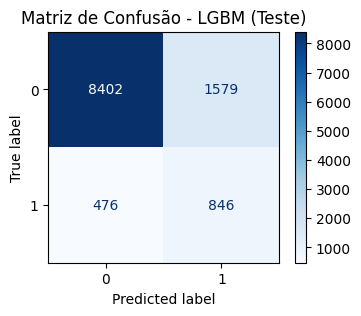

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gerando a matriz de confusão para o modelo LGBM
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - LGBM (Teste)')
plt.show()

- TN = 8402 → não ia converter e modelo disse não ✅
- FP = 1579 → não ia converter mas modelo disse sim ⚠️ (ligação desperdiçada)
- FN = 476 → ia converter mas modelo disse não ❌ (perda de cliente)
- TP = 846 → ia converter e modelo disse sim ✅ (capturado!)

O que isso significa para o negócio

- De 1.322 clientes que realmente converteriam, o modelo capturou 846
- Perdeu 476 conversores (FN) - esses são os clientes que o modelo não conseguiu identificar
- Recomendou ligar para 2425 clientes (846 + 1579) em vez de 11.303 - economizou 8.878 ligações!

Os números parecem promissores — economizar 8.878 ligações é significativo. Mas, será que esse equilíbrio entre conversões capturadas e ligações desperdiçadas está realmente gerando lucro pro banco? Isso a gente vai ver em uma próxima aula, que vamos falar sobre ponte de corte, threshold.

In [120]:
import joblib

In [121]:

joblib.dump(modelo_final, "modelo_lighgbm.pkl")

s3 = boto3.client("s3")

s3.upload_file('modelo_lighgbm.pkl', 'bank-marketing-alura', 'modelos/modelo_lighgbm.pkl')

In [122]:
joblib.dump(ohe, "ohe.pkl")
s3.upload_file('ohe.pkl', 'bank-marketing-alura', 'modelos/ohe.pkl')

joblib.dump(oe, "oe.pkl")
s3.upload_file('oe.pkl', 'bank-marketing-alura', 'modelos/oe.pkl')

joblib.dump(scaler, "scaler_age.pkl")
s3.upload_file('scaler_age.pkl', 'bank-marketing-alura', 'modelos/scaler_age.pkl')

joblib.dump(scaler_balance, "scaler_balance.pkl")
s3.upload_file('scaler_balance.pkl', 'bank-marketing-alura', 'modelos/scaler_balance.pkl')

In [123]:
joblib.dump(X_test_pre, "X_test_pre.pkl")
s3.upload_file('X_test_pre.pkl', 'bank-marketing-alura', 'modelos/X_test_pre.pkl')

joblib.dump(y_test, "y_test.pkl")
s3.upload_file('y_test.pkl', 'bank-marketing-alura', 'modelos/y_test.pkl')



# Salvando o modelo no S3

In [ ]:
import joblib

# 1. Salvar localmente
joblib.dump(modelo_final, "modelo_lightgbm.pkl")

# 2. Enviar para o S3
s3 = boto3.client("s3")

s3.upload_file(
    "modelo_lightgbm.pkl",
    "bank-marketing-alura",
    "modelos/modelo_lightgbm.pkl"
)

In [ ]:
# Pra facilitar vamos salvar todos os scalers que salvamos anteriormente no S3 também

# OneHotEncoder
joblib.dump(ohe, "ohe.pkl")

# OrdinalEncoder
joblib.dump(oe, "oe.pkl")

# Scaler de idade
joblib.dump(scaler, "scaler_age.pkl")

# Scaler de balance
joblib.dump(scaler_balance, "scaler_balance.pkl")


s3.upload_file("ohe.pkl", "bank-marketing-alura", "modelos/ohe.pkl")
s3.upload_file("oe.pkl",     "bank-marketing-alura", "modelos/oe.pkl")
s3.upload_file("scaler_age.pkl",     "bank-marketing-alura", "modelos/scaler_age.pkl")
s3.upload_file("scaler_balance.pkl", "bank-marketing-alura", "modelos/scaler_balance.pkl")

In [ ]:
joblib.dump(X_test_pre, "X_test_pre.pkl")
joblib.dump(y_test,     "y_test.pkl")

s3.upload_file("X_test_pre.pkl", "bank-marketing-alura", "modelos/X_test_pre.pkl")
s3.upload_file("y_test.pkl",     "bank-marketing-alura", "modelos/y_test.pkl")

# Limiar de decisão (threshold)

Bom, até aqui analisamos o desempenho do modelo utilizando métricas como Recall, Precision e F1-score. Essas métricas nos ajudam a entender como o modelo se comporta em relação aos diferentes tipos de erro e acerto.

No entanto, em problemas de negócio, avaliar apenas as métricas tradicionais nem sempre é suficiente.

No contexto desta campanha de marketing, pequenas mudanças no threshold (ponto de corte) podem alterar significativamente a quantidade de clientes contatados, o número de conversões capturadas e até mesmo o custo operacional da campanha.

Por isso, nesta etapa, iremos analisar como diferentes thresholds impactam o equilíbrio entre recall, precision e resultado financeiro esperado, aproximando a análise de um cenário mais próximo da realidade do negócio.

**Mas primeiro, o que é threshold, ponto de corte?** 

O modelo não entrega diretamente "vai assinar" ou "não vai". Ele entrega uma **probabilidade** — por exemplo, 0.63. O threshold é o valor que você define pra transformar essa probabilidade numa decisão binária:

*Se a probabilidade de assinar for maior que X, recomenda ligar pra esse cliente.*

Por padrão esse X é 0.5. Ou seja,  qualquer cliente com probabilidade acima de 50% é classificado como positivo.

<img src="/Users/leticiapires/Desktop/dev/BankMarketing/imagens_ilustrativas/threshold_padrao.png" width="700">

A consequência nesse caso, de alterar o ponto de corte é justamente o equilibrio ou troca entre precision e recall, normalmente você melhora um e piora outro.

- quando temos um ponto de corte alto, 0.8, temos um modelo mais conservador, ou seja, liga apenas para quem tem alta chance de converter. Resultado menos ligações desperdiçadas (precision alta), mas perde mais clientes que iriam converter (Recall baixo).
    - Em bloqueadores de transações bancárias no cartão de crédito. É melhor pedir para o cliente ligar no banco para aprovar uma compra legítima (falso positivo) do que não bloquear uma compra feita por um fraudador (falso negativo).
- Ponto de corte baixo (0.2) modelo mais sensivel. Liga pra quase todo mundo com qualquer sinal de interesse. Resultado captura mais conversores (recall alto), mas desperdiça mais ligações (precision baixo)
    - Outro exemplo, num diagnóstico de doença, deixar de detecar um caso real pode custar uma vida, melhor dar mais alarmes falsos do que perder um paciente doente, priorizar recall.


<img src="/Users/leticiapires/Desktop/dev/BankMarketing/imagens_ilustrativas/threshold_alto_baixo.png" width="700">

O Google possui um material interativo muito interessante sobre threshold:
[Google Machine Learning Crash Course — Thresholding](https://developers.google.com/machine-learning/crash-course/classification/thresholding)

Nesse link, é possível visualizar como o threshold alto ou baixo impacta diretamente os resultados do negócio, através da matriz de confusão.



**Mas então, qual ponto de corte escolher?**

Não existe modelo perfeito que maximize tudo ao mesmo tempo. A resposta depende do problema e do custo de cada tipo de erro. O negócio é que vai decidir o que é pior

**No nosso caso de bank marketing, os dois erros têm custos diferentes:**

- Falso Negativo — deixamos de ligar pra um cliente que ia assinar. Custo: receita perdida.
- Falso Positivo — ligamos pra um cliente que não ia assinar. Custo: tempo e dinheiro da ligação.

A pergunta certa então não é "qual métrica maximizar?" — é **"qual ponto de corte faz a campanha gerar mais lucro?"**

É exatamente isso que vamos ver na próxima aula

# Identificando o limiar de decisão ideal

*Bom, para definir esse limiar ideal de decisão em um problema de classificação, existem diversos métodos estatísticos que podemos utilizar. Entre eles, temos a curva ROC, a curva Precision-Recall, média geométrica, coeficiente de correlação de Matthews, entre muitos outros.*

*Além disso, também podemos construir modelos de negócio personalizados, focados em maximizar métricas comerciais e operacionais.*

*Porque, na prática, nem sempre o threshold que parece ideal no código realmente faz sentido quando aplicamos no contexto do negócio.*

Então nessa aula aqui, a gente vai focar em analisar o limiar ideal que traz mais valor do ponto de vista comercial. 

Vamos primeiro analisar aqui o impacto do limiar em relação as ligações.

In [ ]:
pontos = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80]
baseline = len(y_test)
resumo_negocio = []


for corte in pontos:

    y_pred_corte = (y_prob_test >= corte).astype(int)

    TP = ((y_pred_corte == 1) & (y_test.values == 1)).sum()
    FP = ((y_pred_corte == 1) & (y_test.values == 0)).sum()

    ligacoes_feitas = TP + FP
    ligacoes_economizadas = baseline - ligacoes_feitas
    conversores_capturados = TP
    total_conversores = y_test.sum()


    resumo_negocio.append({
        'Ponto de Corte': corte,
        'Ligações Feitas': ligacoes_feitas,
        'Ligações Economizadas': ligacoes_economizadas,
        'Conversores Capturados': conversores_capturados,
        'Precisão': round(TP / ligacoes_feitas if ligacoes_feitas > 0 else 0, 3),
        'Recall': round(TP / total_conversores, 3)
    })

display(pd.DataFrame(resumo_negocio).set_index('Ponto de Corte'))



,Ligações Feitas,Ligações Economizadas,Conversores Capturados,Precisão,Recall
Ponto de Corte,,,,,
0.25,7172,4131,1175,0.164,0.889
0.30,5797,5506,1114,0.192,0.843
0.35,4636,6667,1036,0.223,0.784
0.40,3736,7567,973,0.260,0.736
0.45,3024,8279,917,0.303,0.694
0.50,2425,8878,846,0.349,0.640
0.55,1973,9330,782,0.396,0.592
0.60,1664,9639,724,0.435,0.548
0.65,1428,9875,671,0.470,0.508


O threshold de 0.7 é o ponto onde precisão e recall praticamente se encontram — ambos em torno de 0.50. Isso significa que metade das ligações feitas resultam em conversão, mas o modelo captura apenas 633 dos conversores reais de 1.322). Em outras palavras, a operação fica mais enxuta e eficiente, porém cerca de 689 clientes com potencial real de conversão deixam de ser abordados.

Para equipes com capacidade de atendimento limitada ou custos operacionais elevados, esse pode ser um ponto interessante, já que reduz significativamente o número de contatos realizados. Por outro lado, thresholds mais baixos aumentam o recall e permitem capturar mais oportunidades de venda, ainda que isso também aumente o número de ligações para clientes que não irão converter.

O range entre 0.35 e 0.45 costuma representar um equilíbrio mais interessante entre escala e eficiência. Com threshold 0.40, por exemplo, o modelo ainda captura cerca de 73% dos conversores reais realizando apenas 33% do total de ligações — uma redução expressiva de esforço operacional sem abrir mão da maior parte das oportunidades de receita.

Na prática, a escolha ideal depende principalmente de alguns fatores do negócio, como a capacidade operacional da equipe, o custo de cada contato realizado, o valor médio gerado por cada conversão, por exemplo.

---

Agora, se a gente mudar a pergunta, e pensar em termos de maximizar o lucro considerando um cenário especifico, qual ponto de corte que maximiza o resultado financeiro?

Vamos considerar uma campanha com  R$600,00 por conversão e R$45 por ligação pra ilustrar o raciocínio. Isso que a gente vai fazer é uma situação bem simples, e pra analisar lucro direto. Esses números são hipotéticos — na prática real de um banco, o modelo seria muito mais sofisticado. Vocês trabalhariam junto com o time de negócio pra calibrar esses valores com dados reais, considerando aspectos como margem financeira, valor do relacionamento de longo prazo com o cliente, custo real do call center e custo de oportunidade de cada conversor perdido.”

Nesse caso, estou fazendo um exemplo muito simples, e considerando zero custo de perder um conversor por exemplo, considerando deixar de ganhar e não como receita perdida.

In [186]:
RECEITA_CONVERSAO = 600
CUSTO_LIGACAO = 45


total_ligacoes = len(y_test)
total_conversores = int(y_test.sum())
receita_base = total_conversores * RECEITA_CONVERSAO
custo_base = total_ligacoes * CUSTO_LIGACAO
lucro_base = receita_base - custo_base

print(f"{'='*55}")
print(f"BASELINE - sem modelo, liga pra todo mundo")
print(f"{'='*55}")
print(f"Ligações realizadas : {total_ligacoes:>7,}")
print(f"Conversores reais   : {total_conversores:>7,}")
print(f"Receita             : R${receita_base:>10,.0f}")
print(f"Custo               : R${custo_base:>10,.0f}")
print(f"Lucro               : R${lucro_base:>10,.0f}")

pontos = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80]
resultados = []

for corte in pontos:
    y_pred_corte = (y_prob_test >= corte).astype(int)

    cm = confusion_matrix(y_test, y_pred_corte)
    tn, fp, fn, tp = cm.ravel()


    receita = tp * RECEITA_CONVERSAO
    custo = (tp + fp)*CUSTO_LIGACAO
    lucro = receita - custo


    resultados.append({
        'Ponto de Corte': corte,
        'Ligações feitas': tp + fp,
        'Ligações economizadas': total_ligacoes - (tp + fp),
        'Conversores capturados': tp,
        'Receita (R$)': receita,
        'Custo (R$)': custo,
        'Lucro (R$)': lucro
    })

df_negocio = pd.DataFrame(resultados).set_index('Ponto de Corte')

melhor_ponto = df_negocio['Lucro (R$)'].idxmax()
melhor_lucro = df_negocio['Lucro (R$)'].max()

print(f"{'='*55}")
print(f"CONTEXTO NEGÓCIO - THRESHOLD")
print(f"{'='*55}")
print(df_negocio.to_string())
print(f"Ponto de corte: {melhor_ponto:.2f}")
print(f"Lucro máximo: R${melhor_lucro:,.0f}")


BASELINE - sem modelo, liga pra todo mundo
Ligações realizadas :  11,303
Conversores reais   :   1,322
Receita             : R$   793,200
Custo               : R$   508,635
Lucro               : R$   284,565
CONTEXTO NEGÓCIO - THRESHOLD
                Ligações feitas  Ligações economizadas  Conversores capturados  Receita (R$)  Custo (R$)  Lucro (R$)
Ponto de Corte                                                                                                      
0.25                       7172                   4131                    1175        705000      322740      382260
0.30                       5797                   5506                    1114        668400      260865      407535
0.35                       4636                   6667                    1036        621600      208620      412980
0.40                       3736                   7567                     973        583800      168120      415680
0.45                       3024                   8279       

*Em resumo, não existe threshold universalmente certo. O threshold ideal depende do contexto do negócio, dos custos envolvidos e do que a empresa prioriza. Se o call center tiver capacidade limitada, talvez 0.70 faça mais sentido operacionalmente. Se o objetivo for maximizar conversões a qualquer custo, 0.25 talvez seria o melhor.* 

Então, pra esse projeto, vou considerar o 0.40 como threshold ideal — ele maximiza o lucro considerando o trade-off entre receita por conversão e custo de ligação. Com esse limiar definido, já temos tudo que precisamos para simular uma campanha real. Na próxima aula, vamos aplicar o modelo em novos clientes e ver como isso funciona na prática. 

# Simulação novos clientes

*Bom, ao longo dessas aulas construímos o modelo, avaliamos, ajustamos o threshold e entendemos o impacto financeiro de cada decisão. Mas agora, como isso vira um produto que alguém realmente usa no dia a dia?*
*Pensa no operador do call center chegando de manhã. Ele não quer saber de AUC, matriz de confusão, threshold. Ele quer saber uma coisa só: pra quem eu ligo hoje?*

Bom, então é isso que vamos fazer. *Se o banco receber dados de novos clientes amanhã, o modelo vai processar tudo e devolver uma lista ordenada: começa por esse, depois esse, esse não vale a pena ligar, e assim port diante.*

In [167]:
novos_clientes = pd.read_csv("novos_clientes_simulacao.csv")
novos_clientes.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome
0,56,blue-collar,divorced,primary,no,4923,yes,yes,cellular,20,jun,2,2,failure
1,69,technician,divorced,tertiary,no,14089,no,no,cellular,10,may,2,3,unknown
2,46,technician,single,tertiary,no,11415,no,yes,cellular,6,jul,1,4,failure
3,32,admin.,divorced,primary,no,4048,no,no,telephone,15,jun,3,4,unknown
4,60,technician,single,primary,no,2608,no,yes,telephone,22,aug,2,3,success


In [168]:
def preparar_novos_clientes(novos_clientes, ohe, oe, scaler, scaler_balance, colunas_treino):
    X_new = novos_clientes.copy()

    # 1. OneHotEncoder: month, job, marital, contact
    cat_cols = ['month', 'job', 'marital', 'contact']

    new_encoded = pd.DataFrame(
        ohe.transform(X_new[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=X_new.index
    )

    X_new = pd.concat([X_new.drop(columns=cat_cols), new_encoded], axis=1)

    # 2. Education ordinal
    X_new['education_ord'] = oe.transform(X_new[['education']])
    X_new.drop(columns=['education'], inplace=True)

    # 3. Age scaler
    X_new['age_t'] = scaler.transform(X_new[['age']])
    X_new.drop(columns=['age'], inplace=True)

    # 4. Balance transform
    X_new['balance_sign'] = np.sign(X_new['balance'])
    X_new['balance_log'] = np.log(X_new['balance'].abs() + 1)
    X_new['balance_log'] = scaler_balance.transform(X_new[['balance_log']])
    X_new.drop(columns=['balance'], inplace=True)

    # 5. Campaign bin
    bins = [0, 1, 3, 6, float('inf')]
    labels = ['1_contato', '2_3_contatos', '4_6_contatos', '7+_contatos']

    X_new['campaign_bin'] = pd.cut(X_new['campaign'], bins=bins, labels=labels)
    X_new.drop(columns=['campaign'], inplace=True)

    X_new = pd.get_dummies(X_new, columns=['campaign_bin'])

    # 6. Binary columns
    binary_map = {'no': 0, 'yes': 1}

    for col in ['default', 'housing', 'loan']:
        X_new[f'{col}_bin'] = X_new[col].map(binary_map)

    X_new.drop(columns=['default', 'housing', 'loan'], inplace=True)

    # 7. Drop pdays se existir
    if 'pdays' in X_new.columns:
        X_new.drop(columns=['pdays'], inplace=True)

    # 8. Previous
    X_new['previous'] = (X_new['previous'] > 0).astype(int)

    # 9. Poutcome
    poutcome_map = {
        'unknown': 0,
        'failure': 1,
        'other': 1,
        'success': 2
    }

    X_new['poutcome'] = X_new['poutcome'].map(poutcome_map)

    # 10. Garantir mesmas colunas do treino
    X_new = X_new.reindex(columns=colunas_treino, fill_value=0)

    return X_new

Mais pra frente, vocês vão aprender mais sobre os pipelines do sklearn, e isso vai facilitar bastante pra que a gente não precise ficar repetindo essas transformações.

In [170]:
X_novos = preparar_novos_clientes(
    novos_clientes,
    ohe,
    oe,
    scaler,
    scaler_balance,
    X_train_pre.columns
)

X_novos.head()

,day,previous,poutcome,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,...,default_bin,housing_bin,loan_bin,age_t,balance_sign,balance_log,campaign_bin_1_contato,campaign_bin_2_3_contatos,campaign_bin_4_6_contatos,campaign_bin_7_contatos
0,20,1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,1,1,1.421072,1,1.188221,False,True,False,0
1,10,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,2.645157,1,1.641823,False,True,False,0
2,6,1,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,1,0.479469,1,1.551025,True,False,False,0
3,15,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,-0.838776,1,1.103807,False,True,False,0
4,22,1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,1.797714,1,0.914184,False,True,False,0


In [171]:
X_novos.columns

Index(['day', 'previous', 'poutcome', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'education_ord', 'default_bin', 'housing_bin', 'loan_bin', 'age_t',
       'balance_sign', 'balance_log', 'campaign_bin_1_contato',
       'campaign_bin_2_3_contatos', 'campaign_bin_4_6_contatos',
       'campaign_bin_7_contatos'],
      dtype='object')

In [172]:
probs = modelo_final.predict_proba(X_novos)[:, 1]

threshold = 0.40

resultado = novos_clientes.copy()

resultado["probabilidade_conversao"] = probs

resultado["decisao"] = np.where(probs >= threshold, "Ligar", "Não ligar")

resultado = resultado.sort_values(by="probabilidade_conversao", ascending=False)

resultado.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,probabilidade_conversao,decisao
37,68,blue-collar,divorced,secondary,no,4473,no,no,cellular,26,jun,4,2,success,0.958375,Ligar
31,44,technician,divorced,primary,yes,5092,yes,no,cellular,30,jun,3,3,success,0.942906,Ligar
36,64,blue-collar,divorced,primary,no,13707,yes,no,cellular,28,jun,3,0,success,0.932719,Ligar
42,68,admin.,divorced,tertiary,no,11483,yes,no,cellular,21,aug,3,3,success,0.928194,Ligar
4,60,technician,single,primary,no,2608,no,yes,telephone,22,aug,2,3,success,0.927063,Ligar
49,42,admin.,divorced,secondary,no,3993,no,no,cellular,26,may,2,0,success,0.925148,Ligar
9,40,blue-collar,divorced,secondary,no,6900,no,yes,telephone,8,aug,2,2,success,0.921905,Ligar
21,47,technician,single,primary,no,12415,no,no,telephone,15,jul,4,4,success,0.916284,Ligar
39,69,admin.,married,primary,no,11469,no,yes,cellular,26,aug,1,1,success,0.915008,Ligar
26,29,blue-collar,divorced,primary,no,3699,yes,no,telephone,16,jul,2,3,success,0.907478,Ligar


In [173]:
resultado.tail(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,probabilidade_conversao,decisao
18,19,technician,married,tertiary,no,10883,no,yes,cellular,13,may,4,0,unknown,0.434077,Ligar
20,61,services,divorced,tertiary,no,11683,no,yes,cellular,30,may,1,1,unknown,0.418797,Ligar
1,69,technician,divorced,tertiary,no,14089,no,no,cellular,10,may,2,3,unknown,0.392349,Não ligar
23,19,blue-collar,single,secondary,no,1148,yes,yes,telephone,23,aug,4,4,unknown,0.384746,Não ligar
46,56,blue-collar,married,primary,no,7852,yes,no,telephone,12,may,1,2,unknown,0.346890,Não ligar
7,56,blue-collar,married,tertiary,no,6658,yes,yes,telephone,5,aug,1,2,unknown,0.329176,Não ligar
10,28,blue-collar,single,secondary,no,2670,yes,yes,cellular,21,may,4,0,unknown,0.310611,Não ligar
22,55,technician,divorced,tertiary,no,12374,yes,yes,cellular,3,jul,4,1,unknown,0.268445,Não ligar
12,41,management,single,secondary,no,14651,no,yes,cellular,12,may,2,4,failure,0.266127,Não ligar
48,21,management,divorced,primary,no,6444,no,yes,telephone,1,aug,4,0,failure,0.258670,Não ligar


*E é isso, agora temos uma lista ordenada do cliente com maior chance de converter pro menor, com a decisão já tomada: liga ou não liga.*

*O operador do call center não precisa saber nada de machine learning. Ele abre essa lista de manhã e começa pelo primeiro.*

*Esse é o ciclo completo de um projeto de machine learning: entender o problema, construir o modelo, avaliar, ajustar pro negócio, e entregar uma decisão que gera valor real.*

*Na próxima aula vamos dar o último passo — transformar isso numa aplicação Streamlit com três abas, onde qualquer pessoa consegue explorar os dados, simular o impacto do threshold e simular um cliente específico. Tudo que construímos até aqui vai ser reaproveitado — só vamos empacotar numa interface que qualquer um consegue usar.*